In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


datasets = ["internal_test", "cta_rsna_ane", "cmha", "hospital140"]


models = [["cpmnet", "50k"], ["decoder_only_no_rec_input_edt", "50k"]]


path_results = "../results/"

modes = ["mode_base", "mode_1", "mode_5"]


df_header = [
    "dataset",
    "model",
    "n_iters",
    "mode",
    "Se@0.1",
    "Se@0.5",
    "Se@1.0",
    "Se@2.0",
]
df_results = []

for dataset in datasets:
    for model in models:
        model_name = model[0]
        n_iters = model[1]
        for mode in modes:
            path_csv = (
                Path(path_results)
                / f"{dataset}/{model_name}/{mode}/iou0.1_froc_{n_iters}/froc.csv"
            )
            if not path_csv.exists():
                print(f"File {path_csv} does not exist, skipping...")
                continue
            df = pd.read_csv(path_csv)
            se_0_1 = df.iloc[0, 1]
            se_0_5 = df.iloc[0, 3]
            se_1_0 = df.iloc[0, 4]
            se_2_0 = df.iloc[0, 5]
            df_results.append(
                [dataset, model_name, n_iters, mode, se_0_1, se_0_5, se_1_0, se_2_0]
            )

df_results = pd.DataFrame(df_results, columns=df_header)

In [17]:
df_results

,dataset,model,n_iters,mode,Se@0.1,Se@0.5,Se@1.0,Se@2.0
0,internal_test,cpmnet,50k,mode_base,0.786,0.937,0.968,0.968
1,internal_test,cpmnet,50k,mode_1,0.794,0.937,0.960,0.960
2,internal_test,cpmnet,50k,mode_5,0.833,0.929,0.944,0.952
3,internal_test,decoder_only_no_rec_input_edt,50k,mode_base,0.897,0.960,0.984,0.984
4,internal_test,decoder_only_no_rec_input_edt,50k,mode_1,0.889,0.968,0.976,0.976
5,internal_test,decoder_only_no_rec_input_edt,50k,mode_5,0.881,0.952,0.960,0.960
6,cta_rsna_ane,cpmnet,50k,mode_base,0.561,0.739,0.804,0.850
7,cta_rsna_ane,cpmnet,50k,mode_1,0.578,0.749,0.813,0.858
8,cta_rsna_ane,cpmnet,50k,mode_5,0.627,0.772,0.824,0.861
9,cta_rsna_ane,decoder_only_no_rec_input_edt,50k,mode_base,0.734,0.868,0.891,0.914


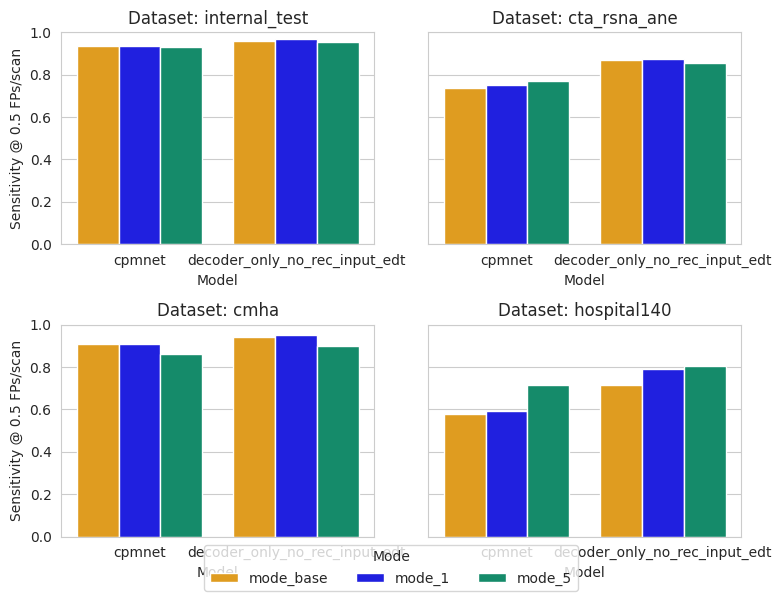

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6), sharey=True, dpi=100)

# set title


for i, dataset in enumerate(datasets):
    df_plot = df_results[df_results["dataset"] == dataset]
    sns.barplot(data=df_plot, x="model", y="Se@0.5", hue="mode", ax=ax[i // 2, i % 2])
    ax[i // 2, i % 2].set_title(f"Dataset: {dataset}")
    ax[i // 2, i % 2].set_ylim(0, 1)
    ax[i // 2, i % 2].set_ylabel("Sensitivity @ 0.5 FPs/scan")
    ax[i // 2, i % 2].set_xlabel("Model")
    # ax[i//2, i%2].legend(title="Mode")
# print legend once outside
# remove all legend
for i in range(2):
    for j in range(2):
        ax[i, j].get_legend().remove()
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Mode", loc="lower center", ncol=len(modes))


plt.tight_layout()

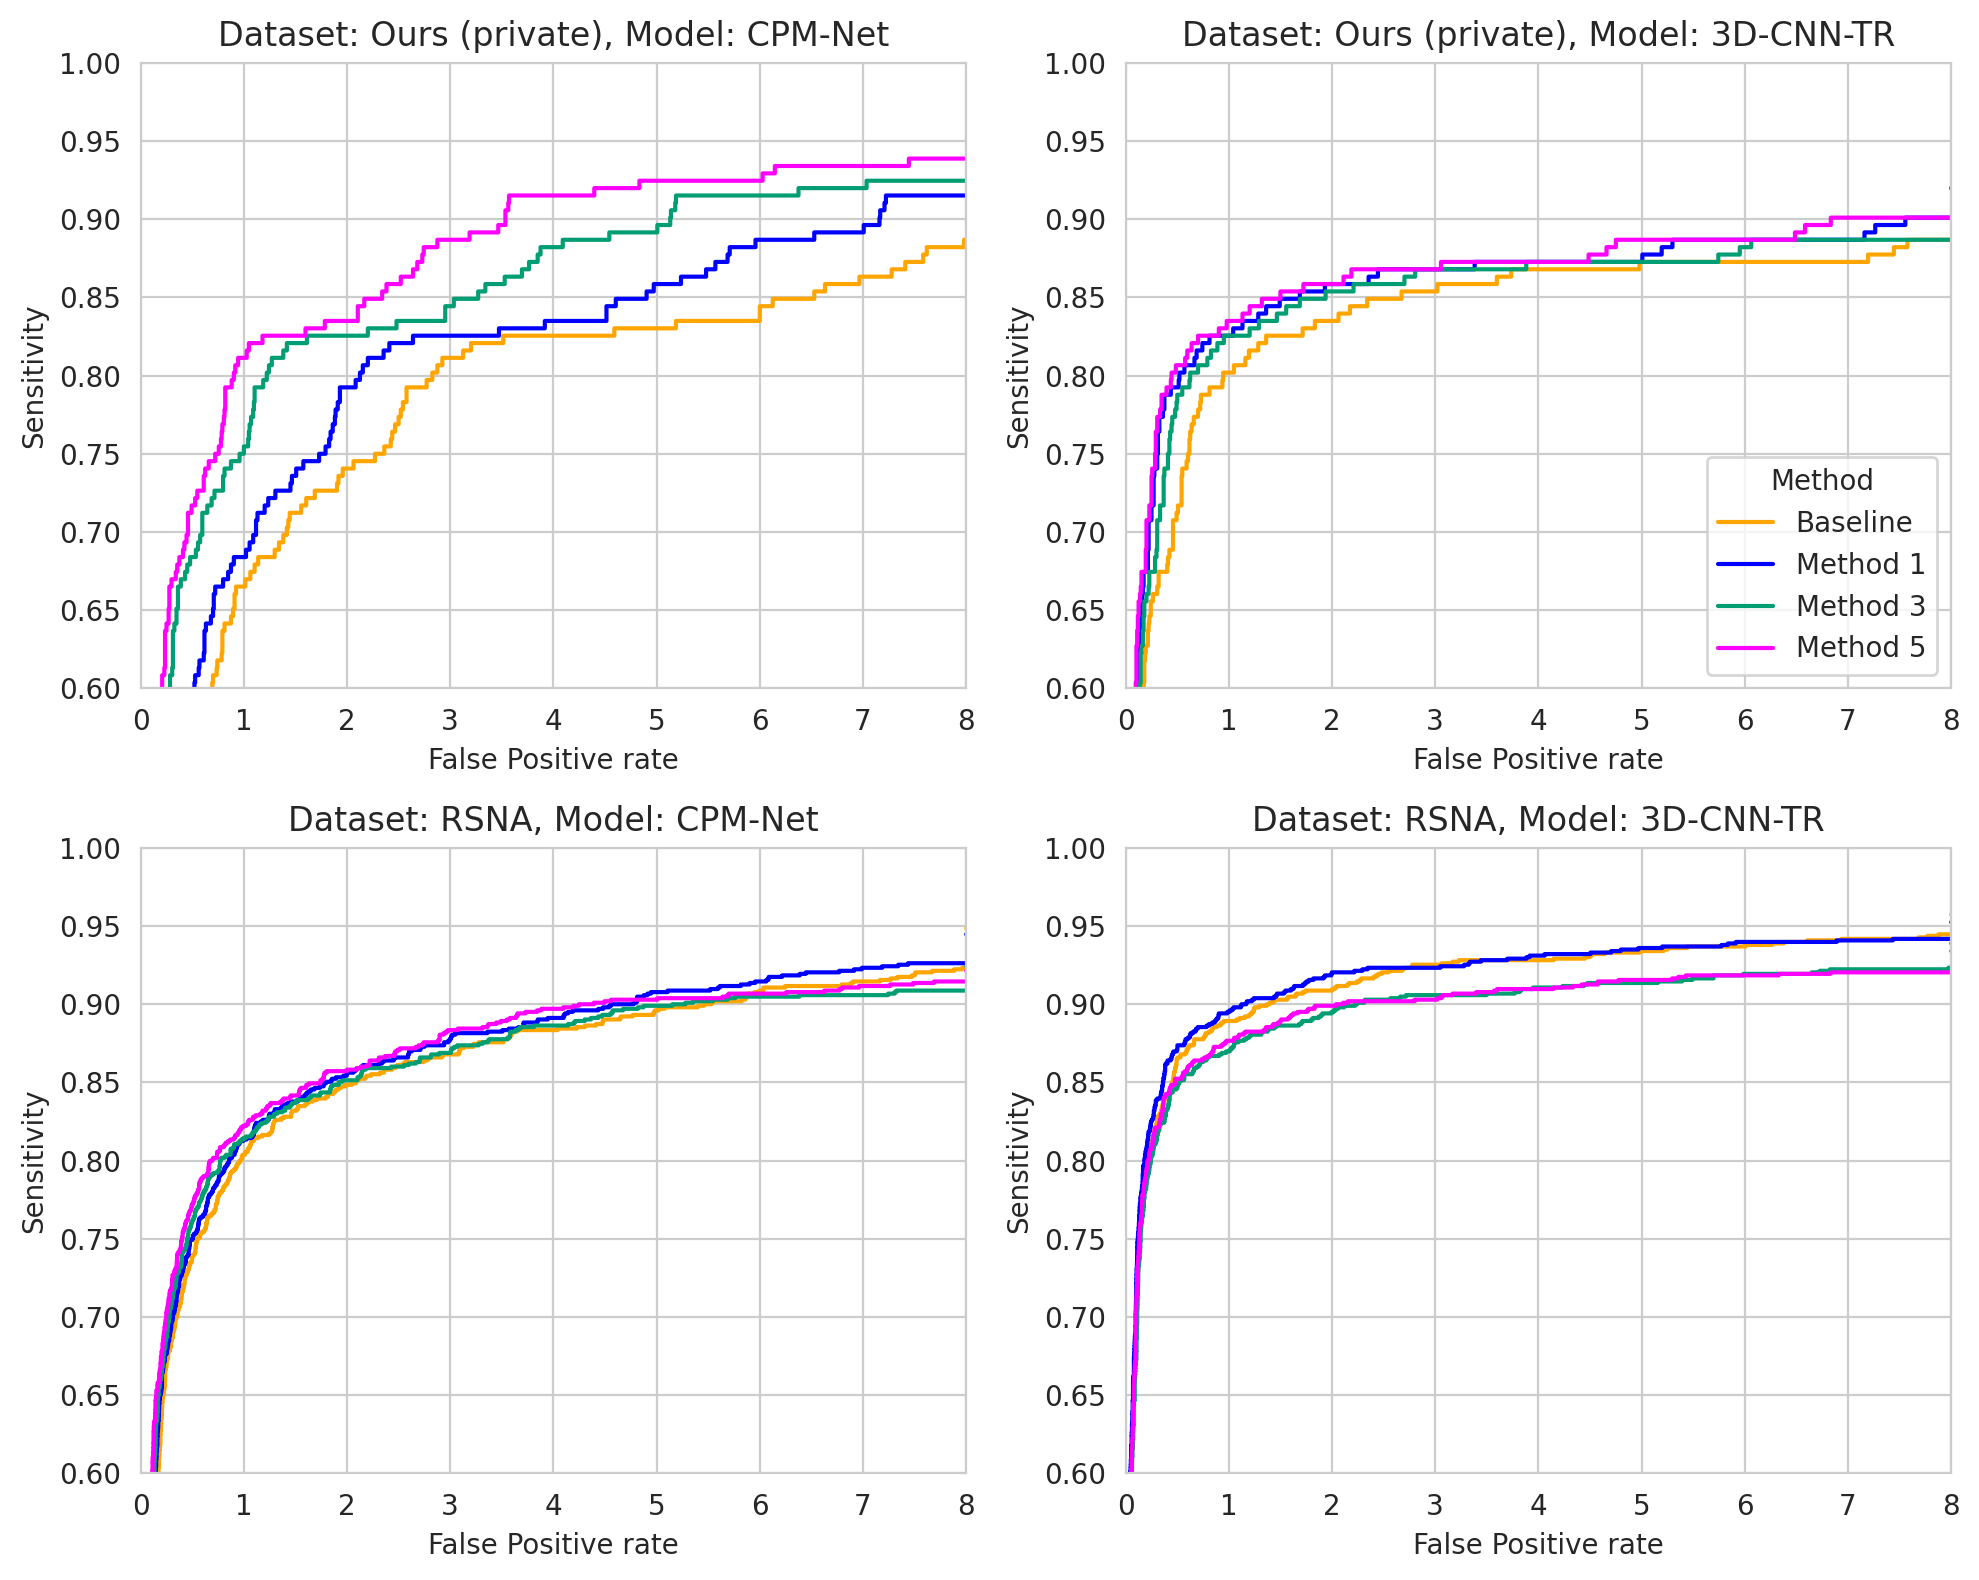

In [20]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# set color map

sns.set_palette("colorblind")

datasets = ["hospital140", "cta_rsna_ane"]


models = [["cpmnet", "50k"], ["decoder_only_no_rec_input_edt", "50k"]]


path_results = "../results/"

modes = [
    "mode_base",
    "mode_1",
    # "mode_2",
    "mode_3",
    # "mode_4",
    "mode_5",
]

model_map = {
    "cpmnet": "CPM-Net",
    "decoder_only_no_rec_input_edt": "3D-CNN-TR",
}

dataset_map = {
    "hospital140": "Ours (private)",
    "cta_rsna_ane": "RSNA",
}

mode_map = {
    "mode_base": "Baseline",
    "mode_1": "Method 1",
    # "mode_2": "Method 2",
    "mode_3": "Method 3",
    # "mode_4": "Method 4",
    "mode_5": "Method 5",
}


color_list = sns.color_palette("colorblind", n_colors=len(modes) * 3)
# randomize the list

colors = ["orange", "blue", color_list[2], "magenta"]
sns.set_palette(colors)

# figure with 1, 2 subplots

total_tp = 1027
total_scans = 843
iou = 0.2
fig, ax = plt.subplots(2, 2, figsize=(10, 8), dpi=200)
for j, model in enumerate(models):
    for i, dataset in enumerate(datasets):

        model_name = model[0]
        n_iters = model[1]
        df_results = []
        for mode in modes:

            path_sens = (
                Path(path_results)
                / f"{dataset}/{model_name}/{mode}/iou{iou}_froc_{n_iters}/figures/aneurysm_recalls.npy"
            )
            path_FPpi = (
                Path(path_results)
                / f"{dataset}/{model_name}/{mode}/iou{iou}_froc_{n_iters}/figures/aneurysm_FPpI.npy"
            )
            path_thresholds = (
                Path(path_results)
                / f"{dataset}/{model_name}/{mode}/iou{iou}_froc_{n_iters}/thres_aneurysm.npy"
            )
            sens = np.load(path_sens)
            FPpi = np.load(path_FPpi)
            # replicate the last value of both arrays to extend the curve to the right
            sens = np.append(sens, sens[-1])
            FPpi = np.append(FPpi, 8.0)

            # find the index of thres = 0.8, then print the values of Sens*total_gt, FPpi*total scans and total_gt - sens*total_gt
            thres = np.load(path_thresholds)
            idx_08 = np.argmin(np.abs(thres - 0.8))
            # print(
            #     f"Dataset: {dataset_map[dataset]}, Model: {model_map[model_name]}, Mode: {mode_map[mode]}"
            # )
            # print(
            #     f"Threshold: {thres[idx_08]:.3f}, TP: {sens[idx_08]*total_tp:.1f}, FP: {FPpi[idx_08]*total_scans:.1f}, FN: {total_tp - sens[idx_08]*total_tp:.1f}"
            # )
            # print("-----------------------\n")
            ax[i, j].plot(FPpi, sens, label=mode_map[mode])

        ax[i, j].set_title(
            f"Dataset: {dataset_map[dataset]}, Model: {model_map[model_name]}"
        )
        ax[i, j].set_xlabel("False Positive rate")
        ax[i, j].set_ylabel("Sensitivity")
        ax[i, j].set_xlim(0, 8)
        ax[i, j].set_ylim(0.6, 1)
        if i == 0 and j == 1:
            ax[i, j].legend(title="Method", loc="lower right")

plt.tight_layout()

In [21]:
print(len(thres))

7


In [17]:
df_A = pd.read_csv(
    "/projects/vig/alberto/medical/deform-aneurysm-detection/results/cta_rsna_ane/.old/cpmnet_prefix/inference_50k/predict_roi_jisoo_filtered.csv"
)
# get all unique seriesuids
seriesuids = df_A["seriesuid"].unique().tolist()
len(seriesuids)

844

In [18]:
df_A = pd.read_csv(
    "/projects/vig/alberto/medical/deform-aneurysm-detection/results/cta_rsna_ane/cpmnet/inference_50k/predict_roi_jisoo.csv"
)
# get all unique seriesuids
seriesuids = df_A["seriesuid"].unique().tolist()
len(seriesuids)

844

FileNotFoundError: [Errno 2] No such file or directory: '../results/hospital140/cpmnet_prefix/mode_base/iou0.1_froc_50k/figures/aneurysm_recalls.npy'

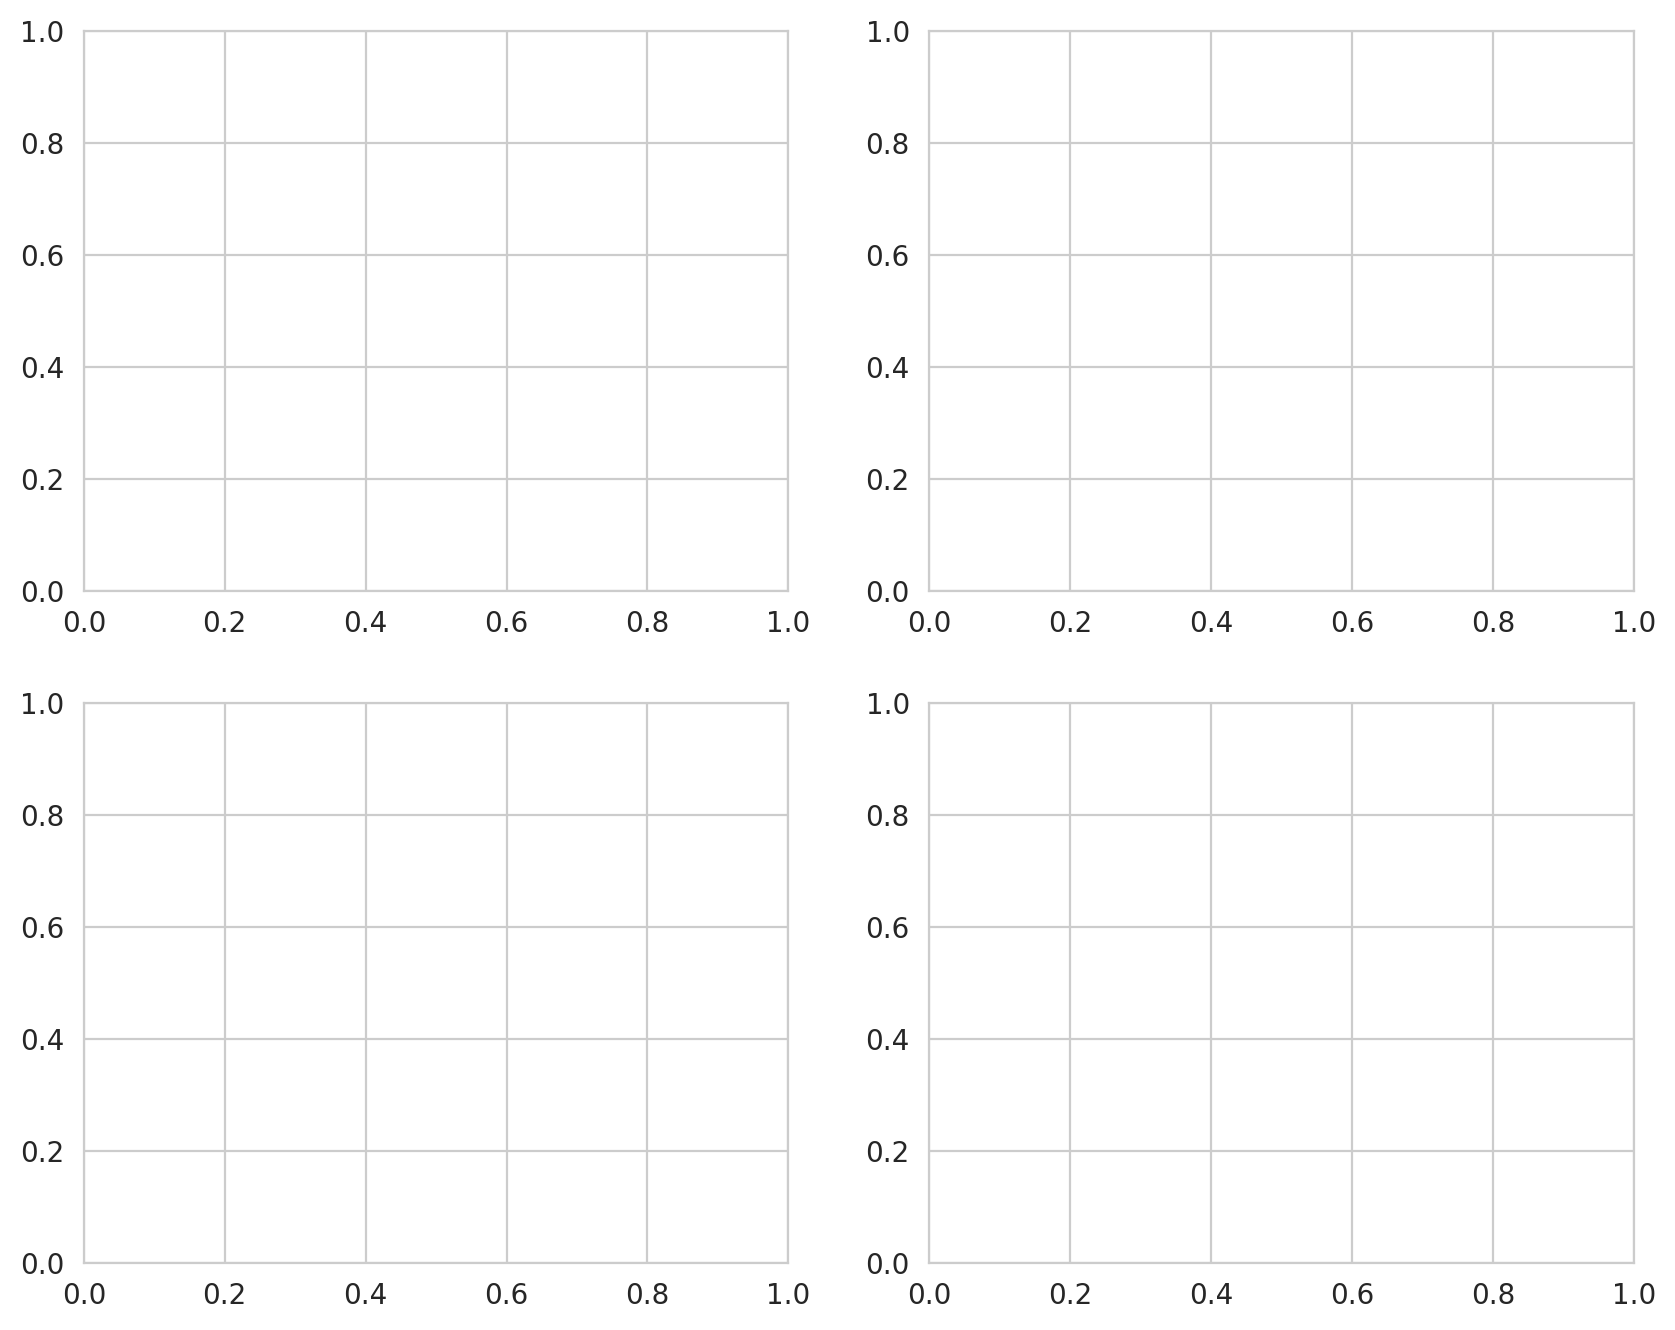

In [20]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# set color map

sns.set_palette("colorblind")

datasets = ["hospital140", "cta_rsna_ane"]


models = [["cpmnet_prefix", "50k"], ["decoder_only_no_rec_input_edt_prefix", "50k"]]


path_results = "../results/"

modes = [
    "mode_base",
    "mode_1",
    # "mode_2",
    "mode_3",
    # "mode_4",
    "mode_5",
]

model_map = {
    "cpmnet_prefix": "CPM-Net",
    "decoder_only_no_rec_input_edt_prefix": "3D-CNN-TR",
}

dataset_map = {
    "hospital140": "Ours (private)",
    "cta_rsna_ane": "RSNA",
}

mode_map = {
    "mode_base": "Baseline",
    "mode_1": "Method 1",
    # "mode_2": "Method 2",
    "mode_3": "Method 3",
    # "mode_4": "Method 4",
    "mode_5": "Method 5",
}


color_list = sns.color_palette("colorblind", n_colors=len(modes) * 3)
# randomize the list

colors = ["orange", "blue", color_list[2], "magenta"]
sns.set_palette(colors)

# figure with 1, 2 subplots

total_tp = 1027
total_scans = 843

fig, ax = plt.subplots(2, 2, figsize=(10, 8), dpi=200)
for j, model in enumerate(models):
    for i, dataset in enumerate(datasets):

        model_name = model[0]
        n_iters = model[1]
        df_results = []
        for mode in modes:
            path_sens = (
                Path(path_results)
                / f"{dataset}/{model_name}/{mode}/iou0.1_froc_{n_iters}/figures/aneurysm_recalls.npy"
            )
            path_FPpi = (
                Path(path_results)
                / f"{dataset}/{model_name}/{mode}/iou0.1_froc_{n_iters}/figures/aneurysm_FPpI.npy"
            )
            path_thresholds = (
                Path(path_results)
                / f"{dataset}/{model_name}/{mode}/iou0.1_froc_{n_iters}/thres_aneurysm.npy"
            )
            sens = np.load(path_sens)
            FPpi = np.load(path_FPpi)
            # replicate the last value of both arrays to extend the curve to the right
            sens = np.append(sens, sens[-1])
            FPpi = np.append(FPpi, 8.0)

            # find the index of thres = 0.8, then print the values of Sens*total_gt, FPpi*total scans and total_gt - sens*total_gt
            thres = np.load(path_thresholds)
            idx_08 = np.argmin(np.abs(thres - 0.8))
            print(
                f"Dataset: {dataset_map[dataset]}, Model: {model_map[model_name]}, Mode: {mode_map[mode]}"
            )
            print(
                f"Threshold: {thres[idx_08]:.3f}, TP: {sens[idx_08]*total_tp:.1f}, FP: {FPpi[idx_08]*total_scans:.1f}, FN: {total_tp - sens[idx_08]*total_tp:.1f}"
            )
            print("-----------------------\n")
            ax[i, j].plot(FPpi, sens, label=mode_map[mode])

        ax[i, j].set_title(
            f"Dataset: {dataset_map[dataset]}, Model: {model_map[model_name]}"
        )
        ax[i, j].set_xlabel("False Positive rate")
        ax[i, j].set_ylabel("Sensitivity")
        ax[i, j].set_xlim(0, 8)
        ax[i, j].set_ylim(0.6, 1)
        if i == 0 and j == 1:
            ax[i, j].legend(title="Method", loc="lower right")

plt.tight_layout()